In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Check number of records in each CSV file
data_dir = '/home/jko/cocpit/final_databases/vgg16/final'
csv_files = list(Path(data_dir).glob('*.csv'))

print("Number of records in each CSV file:\n")

for f in csv_files:
    # Only read the header + get number of rows
    nrows = pd.read_csv(f).shape[0]
    print(f"{f.name}: {nrows} records")

Number of records in each CSV file:

ATTREX.csv: 19637 records
OLYMPEX.csv: 93741 records
ICE_L.csv: 42433 records
AIRS_II.csv: 80600 records
CRYSTAL_FACE_NASA.csv: 41944 records
IPHEX.csv: 37059 records
POSIDON.csv: 22841 records
MACPEX.csv: 2226 records
CRYSTAL_FACE_UND.csv: 335527 records
MC3E.csv: 91647 records
ARM.csv: 26050 records
ISDAC.csv: 63431 records
ESCAPE.csv: 7106 records
MIDCIX.csv: 88857 records


In [3]:
import pandas as pd
from pathlib import Path

# -------------------------------
# Parameters
# -------------------------------
data_dir = '/home/jko/cocpit/final_databases/vgg16/final'
label_col = 'classification'  # original column name

# -------------------------------
# Step 1: Find all CSV files
# -------------------------------
csv_files = list(Path(data_dir).glob('*.csv'))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {data_dir}")

# -------------------------------
# Step 2: Find columns common to all CSVs
# -------------------------------
cols_by_file = [set(pd.read_csv(f, nrows=0).columns) for f in csv_files]
common_cols = sorted(set.intersection(*cols_by_file))
print(f"Common columns ({len(common_cols)}): {common_cols}")

# -------------------------------
# Step 3: Load each CSV, assign campaign, and concatenate
# -------------------------------
dfs = []
for f in csv_files:
    tmp = pd.read_csv(f, usecols=common_cols)
    tmp["campaign"] = f.stem  # assign campaign based on file
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
print(f"\nCombined DataFrame shape: {df.shape}")

# -------------------------------
# Step 4: Canonicalize classification labels (replace original column)
# -------------------------------
LABEL_MAP = {
    # aggregates
    "aggregate": "aggregate",
    "agg": "aggregate",

    # compact irregular
    "compact irregular": "compact_irregular",
    "compact_irreg": "compact_irregular",

    # planar polycrystal
    "planar polycrystal": "planar_polycrystal",
    "planar_polycrystal": "planar_polycrystal",

    # bullet rosettes
    "bullet rosette": "bullet_rosette",
    "bullet": "bullet_rosette",

    # budding rosettes
    "budding rosette": "budding_rosette",
    "budding": "budding_rosette",

    # already canonical
    "sphere": "sphere",
    "column": "column",
    "fragment": "fragment",
    "rimed": "rimed",
}

# Replace the original classification column with cleaned labels
df[label_col] = df[label_col].str.lower().map(LABEL_MAP)

# -------------------------------
# Step 5: Sanity checks
# -------------------------------
print("\nFinal label counts:")
print(df[label_col].value_counts())

unmapped = df.loc[df[label_col].isna(), label_col].unique()
if len(unmapped) > 0:
    print("\n⚠️ Unmapped labels found:")
    print(unmapped)
else:
    print("\n✅ All labels successfully mapped")

# -------------------------------
# Step 6: Done
# -------------------------------
print("\nDataFrame ready with cleaned classification labels and correct campaign assignment:")
print(df.head())

# -------------------------------
# Step 7: Count number of samples per campaign (optional)
# -------------------------------
samples_per_campaign = df["campaign"].value_counts()
print("\nNumber of samples per campaign:")
print(samples_per_campaign)

Common columns (13): ['blur', 'circularity', 'classification', 'complexity', 'contrast', 'equiv_d', 'extreme_points', 'filename', 'filled_circular_area_ratio', 'perim_area_ratio', 'phi', 'roundness', 'solidity']

Combined DataFrame shape: (953099, 14)

Final label counts:
classification
compact_irregular     410860
bullet_rosette        164973
column                105512
aggregate              73952
fragment               61353
planar_polycrystal     43820
budding_rosette        43296
sphere                 28538
rimed                  20795
Name: count, dtype: int64

✅ All labels successfully mapped

DataFrame ready with cleaned classification labels and correct campaign assignment:
                  filename     classification     blur  contrast  circularity  \
0  2014_0304_174132_21.png    budding_rosette  330.933    99.841        0.461   
1   2014_0304_174132_0.png           fragment  636.623    99.142        0.731   
2   2014_0304_174132_2.png     bullet_rosette  361.354    98.18

In [4]:
# unique habit labels 
print(f'There are {len(df.classification.unique())} unique labels.')
df.classification.unique()

There are 9 unique labels.


array(['budding_rosette', 'fragment', 'bullet_rosette',
       'compact_irregular', 'sphere', 'column', 'aggregate',
       'planar_polycrystal', 'rimed'], dtype=object)

In [5]:
# number of unique campaigns 
print(f'There are {len(df.campaign.unique())} unique labels.')
df.campaign.unique()

There are 14 unique labels.


array(['ATTREX', 'OLYMPEX', 'ICE_L', 'AIRS_II', 'CRYSTAL_FACE_NASA',
       'IPHEX', 'POSIDON', 'MACPEX', 'CRYSTAL_FACE_UND', 'MC3E', 'ARM',
       'ISDAC', 'ESCAPE', 'MIDCIX'], dtype=object)

In [6]:
samples_per_campaign = df.groupby("campaign").size()
print(samples_per_campaign)

campaign
AIRS_II               80600
ARM                   26050
ATTREX                19637
CRYSTAL_FACE_NASA     41944
CRYSTAL_FACE_UND     335527
ESCAPE                 7106
ICE_L                 42433
IPHEX                 37059
ISDAC                 63431
MACPEX                 2226
MC3E                  91647
MIDCIX                88857
OLYMPEX               93741
POSIDON               22841
dtype: int64



Total particles per campaign:
campaign
AIRS_II               80600
ARM                   26050
ATTREX                19637
CRYSTAL_FACE_NASA     41944
CRYSTAL_FACE_UND     335527
ESCAPE                 7106
ICE_L                 42433
IPHEX                 37059
ISDAC                 63431
MACPEX                 2226
MC3E                  91647
MIDCIX                88857
OLYMPEX               93741
POSIDON               22841
Name: classification, dtype: int64

Habit proportions per campaign:
classification     aggregate  compact_irregular  planar_polycrystal  \
campaign                                                              
AIRS_II             0.021514           0.467419            0.005620   
ARM                 0.020998           0.383071            0.006104   
ATTREX              0.001579           0.581810            0.000153   
CRYSTAL_FACE_NASA   0.023627           0.543820            0.000310   
CRYSTAL_FACE_UND    0.030337           0.476754            0.018568   
ESC

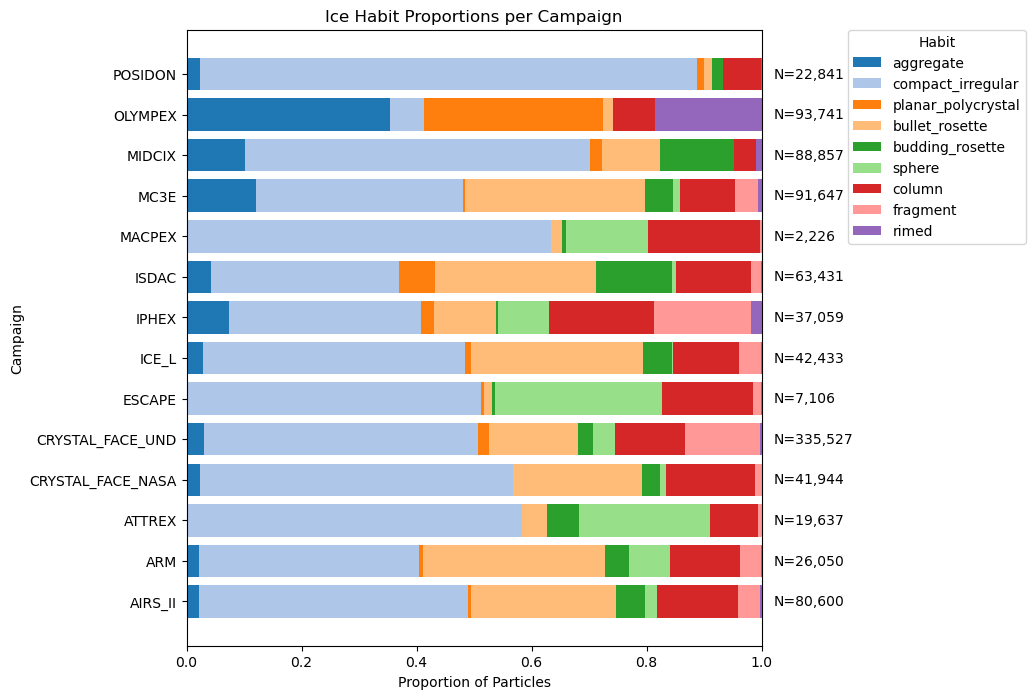

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure all campaigns and all habits are present
campaigns = df["campaign"].unique()
habits = ['aggregate', 'compact_irregular', 'planar_polycrystal',
          'bullet_rosette', 'budding_rosette', 'sphere',
          'column', 'fragment', 'rimed']

# Count total particles per campaign
total_particles = df.groupby("campaign")["classification"].count()
print("\nTotal particles per campaign:")
print(total_particles)

# Compute habit counts and proportions per campaign
habit_counts = df.groupby("campaign")["classification"].value_counts().unstack(fill_value=0)
habit_props = habit_counts[habits].div(habit_counts.sum(axis=1), axis=0)  # normalize properly

print("\nHabit proportions per campaign:")
print(habit_props)

# -------------------------------
# Plot horizontal stacked bar chart
# -------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

left = pd.Series([0]*len(habit_props), index=habit_props.index)

colors = plt.cm.tab20.colors  # 20 distinct colors
for i, habit in enumerate(habits):
    ax.barh(habit_props.index, habit_props[habit], left=left, color=colors[i % 20], label=habit)
    left += habit_props[habit]

# Annotate total particles at the end of each bar
for idx, total in enumerate(total_particles[habit_props.index]):
    ax.text(1.02, idx, f"N={total:,}", va='center', ha='left', fontsize=10)

ax.set_xlabel("Proportion of Particles")
ax.set_ylabel("Campaign")
ax.set_title("Ice Habit Proportions per Campaign")
# Move legend fully outside and reserve space
ax.legend(
    title="Habit",
    bbox_to_anchor=(1.15, 1.0),
    loc="upper left",
    borderaxespad=0
)

# Reserve space on the right for the legend
fig.subplots_adjust(right=0.70)

plt.show()

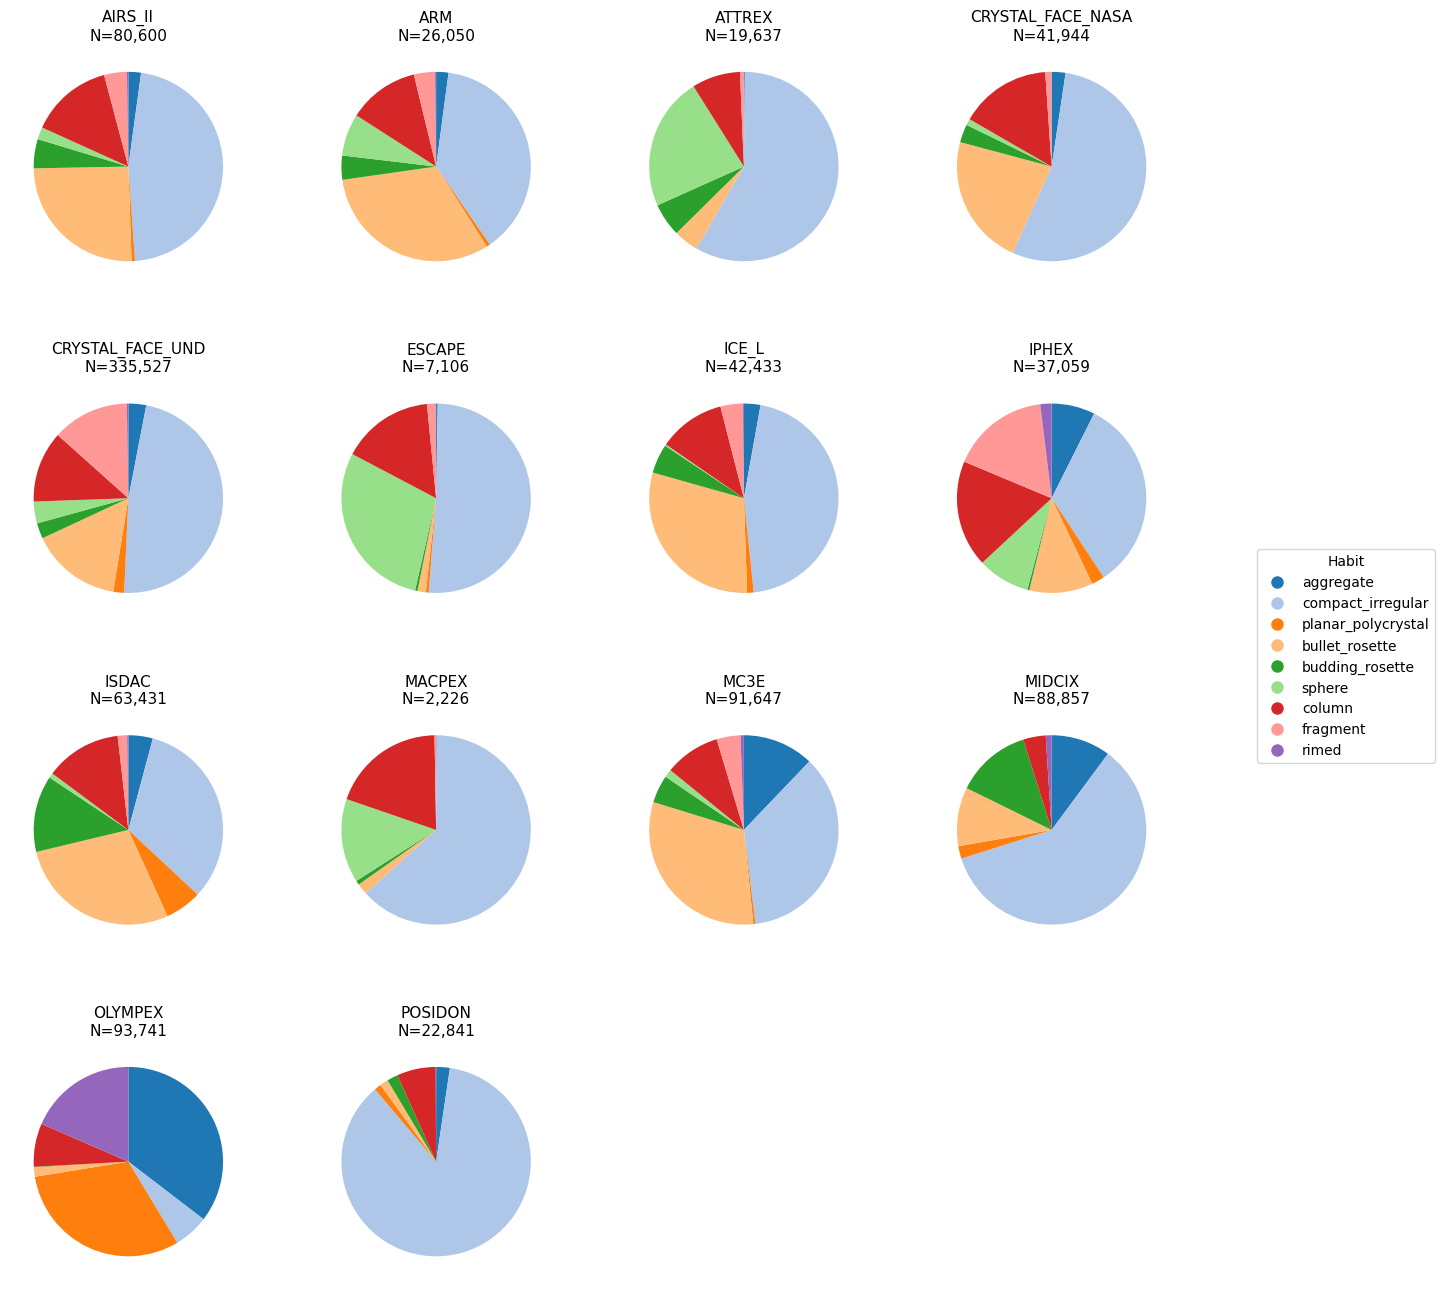

In [12]:
# Grid of barplots instead
import matplotlib.pyplot as plt
import math

# -------------------------------
# Parameters
# -------------------------------
campaigns = habit_props.index.tolist()
n_campaigns = len(campaigns)

ncols = 4  # adjust for layout
nrows = math.ceil(n_campaigns / ncols)

colors = plt.cm.tab20.colors

# -------------------------------
# Create figure
# -------------------------------
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4 * ncols, 4 * nrows),
    subplot_kw=dict(aspect="equal")
)

axes = axes.flatten()

# -------------------------------
# Plot each campaign
# -------------------------------
for ax, campaign in zip(axes, campaigns):
    props = habit_props.loc[campaign]
    counts = habit_counts.loc[campaign]

    # Remove zero-slice habits (cleaner pies)
    mask = props > 0
    props = props[mask]
    labels = props.index
    pie_colors = [colors[habits.index(h) % 20] for h in labels]

    ax.pie(
        props,
        labels=None,           # no labels inside pies
        colors=pie_colors,
        startangle=90,
        counterclock=False
    )

    ax.set_title(f"{campaign}\nN={counts.sum():,}", fontsize=11)

# -------------------------------
# Remove empty subplots
# -------------------------------
for ax in axes[len(campaigns):]:
    ax.axis("off")

# -------------------------------
# Shared legend
# -------------------------------
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=colors[i % 20], markersize=10, label=habit)
    for i, habit in enumerate(habits)
]

fig.legend(
    handles=handles,
    labels=habits,
    title="Habit",
    loc="center right",
    bbox_to_anchor=(1.02, 0.5)
)

fig.subplots_adjust(right=0.85, wspace=0.3, hspace=0.4)
plt.show()

In [14]:
# Check if data is idential between two directories
dir1 = Path('/home/jko/cocpit/final_databases/vgg16/final')
dir2 = Path('/home/vanessa/hulk/cocpit/final_databases/vgg16/v3.1.0')

# Get CSV files in both directories
csv_files1 = {f.name: f for f in dir1.glob('*.csv')}
csv_files2 = {f.name: f for f in dir2.glob('*.csv')}

# Find common CSV names
common_csvs = set(csv_files1.keys()).intersection(csv_files2.keys())

if not common_csvs:
    raise ValueError("No matching CSV files found between the two directories.")

# Check equality
for name in sorted(common_csvs):
    df1 = pd.read_csv(csv_files1[name])
    df2 = pd.read_csv(csv_files2[name])
    
    # Optional: sort columns and rows to ensure correct comparison
    df1_sorted = df1.sort_index(axis=1).sort_values(by=list(df1.columns)).reset_index(drop=True)
    df2_sorted = df2.sort_index(axis=1).sort_values(by=list(df2.columns)).reset_index(drop=True)
    
    identical = df1_sorted.equals(df2_sorted)
    
    print(f"{name}: {'IDENTICAL ✅' if identical else 'DIFFERENT ❌'}")

AIRS_II.csv: IDENTICAL ✅
ARM.csv: IDENTICAL ✅
ATTREX.csv: IDENTICAL ✅
CRYSTAL_FACE_NASA.csv: IDENTICAL ✅
CRYSTAL_FACE_UND.csv: IDENTICAL ✅
ESCAPE.csv: IDENTICAL ✅
ICE_L.csv: IDENTICAL ✅
IPHEX.csv: IDENTICAL ✅
ISDAC.csv: IDENTICAL ✅
MACPEX.csv: IDENTICAL ✅
MC3E.csv: IDENTICAL ✅


NOTE: '/home/jko/cocpit/final_databases/vgg16/final' is from the directory, '/home/vanessa/hulk/cocpit/final_databases/vgg16/v3.1.0'